# Классификация новостей BBC

In [1]:
from pathlib import Path
import re
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

RANDOM_STATE = 42

### 1. Загрузка и первичный осмотр данных

In [2]:
def load_bbc_dataset(data_dir: Path):
    rows = []
    for class_dir in sorted(data_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        label = class_dir.name
        for path in sorted(class_dir.glob('*.txt')):
            raw_text = path.read_text(encoding='latin-1', errors='ignore')
            raw_text = re.sub(r'\s+', ' ', raw_text).strip()
            rows.append({'raw_text': raw_text, 'label': label, 'path': str(path)})
    return pd.DataFrame(rows)


df = load_bbc_dataset(Path('data/bbc'))
print(df.shape)
df.head()

(2221, 3)


,raw_text,label,path
0,Ad sales boost Time Warner profit Quarterly pr...,business,data/bbc/business/001.txt
1,Dollar gains on Greenspan speech The dollar ha...,business,data/bbc/business/002.txt
2,Yukos unit buyer faces loan claim The owners o...,business,data/bbc/business/003.txt
3,High fuel prices hit BA's profits British Airw...,business,data/bbc/business/004.txt
4,Pernod takeover talk lifts Domecq Shares in UK...,business,data/bbc/business/005.txt


### 2. Очистка текста и подготовка датасета

Для классификации используются две версии текстового корпуса. Для классического ML используется очищенный текст: lowercase, удаление небуквенных символов и лишних пробелов. Это снижает шум перед TF-IDF-векторизацией. Для DistilBERT используется только мягкая нормализация
пробелов, без удаления пунктуации и stopwords, так как трансформер обучался на естественном тексте и учитывает контекст токенов.

In [3]:
def clean_for_classical_ml(text: str) -> str:
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def normalize_for_bert(text: str) -> str:
    # Для BERT/DistilBERT не удаляем пунктуацию и stopwords: модель обучалась на естественном тексте.
    return re.sub(r'\s+', ' ', text).strip()


df['clean_text'] = df['raw_text'].apply(clean_for_classical_ml)
df['bert_text'] = df['raw_text'].apply(normalize_for_bert)

df[['label', 'raw_text', 'clean_text', 'bert_text']].head()

,label,raw_text,clean_text,bert_text
0,business,Ad sales boost Time Warner profit Quarterly pr...,ad sales boost time warner profit quarterly pr...,Ad sales boost Time Warner profit Quarterly pr...
1,business,Dollar gains on Greenspan speech The dollar ha...,dollar gains on greenspan speech the dollar ha...,Dollar gains on Greenspan speech The dollar ha...
2,business,Yukos unit buyer faces loan claim The owners o...,yukos unit buyer faces loan claim the owners o...,Yukos unit buyer faces loan claim The owners o...
3,business,High fuel prices hit BA's profits British Airw...,high fuel prices hit ba s profits british airw...,High fuel prices hit BA's profits British Airw...
4,business,Pernod takeover talk lifts Domecq Shares in UK...,pernod takeover talk lifts domecq shares in uk...,Pernod takeover talk lifts Domecq Shares in UK...


label
sport            511
business         506
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


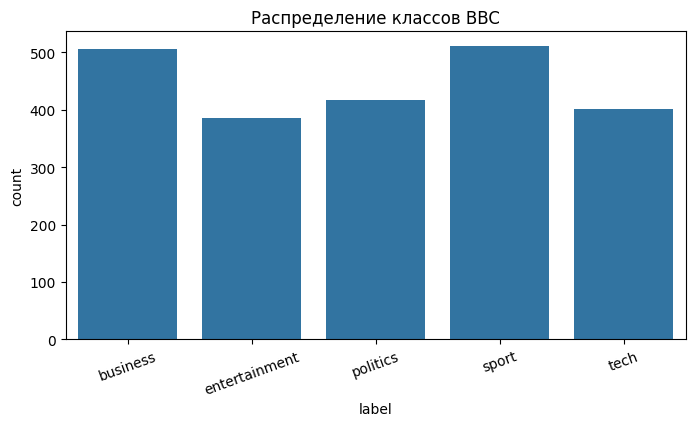

In [4]:
print(df['label'].value_counts())

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='label', order=sorted(df['label'].unique()))
plt.title('Распределение классов BBC')
plt.xticks(rotation=20)
plt.show()

#### Train / test / validation split


In [5]:
label_names = sorted(df['label'].unique())
label2id = {label: i for i, label in enumerate(label_names)}
id2label = {i: label for label, i in label2id.items()}

df['label_id'] = df['label'].map(label2id)

train_df, validation_df = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df['label_id'],
)

train_df, test_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=train_df['label_id'],
)

print('train:', train_df.shape)
print('test:', test_df.shape)
print('validation:', validation_df.shape)
print(label2id)

train: (1509, 6)
test: (267, 6)
validation: (445, 6)
{'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}


### 3. Классический ML baseline: TF-IDF + LogisticRegression

Для классической модели выбрана логистическая регрессия как простая модель которая возвращает вероятности классов.

In [10]:
classic_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

classic_pipeline.fit(train_df['clean_text'], train_df['label'])

classic_pred = classic_pipeline.predict(validation_df['clean_text'])
classic_proba = classic_pipeline.predict_proba(validation_df['clean_text'])

classic_accuracy = accuracy_score(validation_df['label'], classic_pred)
classic_macro_f1 = f1_score(validation_df['label'], classic_pred, average='macro')

print('Accuracy:', round(classic_accuracy, 4))
print('Macro F1:', round(classic_macro_f1, 4))
print()
print(classification_report(validation_df['label'], classic_pred))

Accuracy: 0.9865
Macro F1: 0.9862

               precision    recall  f1-score   support

     business       1.00      0.96      0.98       101
entertainment       1.00      0.99      0.99        77
     politics       0.98      0.99      0.98        84
        sport       1.00      1.00      1.00       103
         tech       0.95      1.00      0.98        80

     accuracy                           0.99       445
    macro avg       0.99      0.99      0.99       445
 weighted avg       0.99      0.99      0.99       445



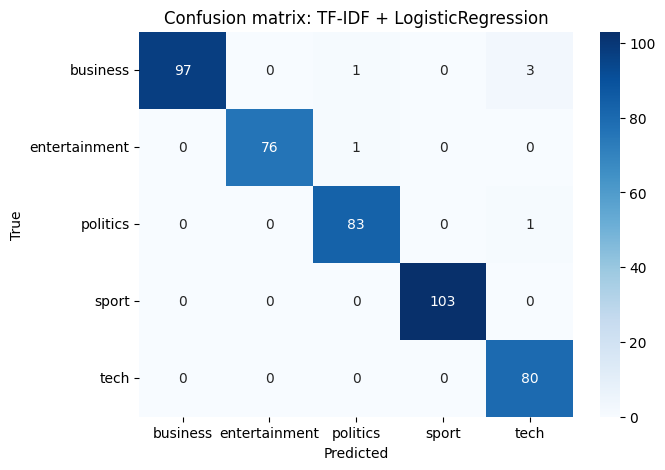

In [7]:
cm = confusion_matrix(validation_df['label'], classic_pred, labels=label_names)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix: TF-IDF + LogisticRegression')
plt.show()

### 4. Пайплайн для инференса с классической моделью

In [8]:
def predict_classical(text: str):
    cleaned = clean_for_classical_ml(text)
    proba = classic_pipeline.predict_proba([cleaned])[0]
    idx = int(np.argmax(proba))
    label = classic_pipeline.classes_[idx]
    return {
        'label': label,
        'probability': float(proba[idx]),
        'all_probabilities': dict(zip(classic_pipeline.classes_, proba.round(4))),
    }

sample_text = validation_df.iloc[0]['raw_text']
print('True label:', validation_df.iloc[0]['label'])
predict_classical(sample_text)

True label: sport


{'label': 'sport',
 'probability': 0.8436117588212247,
 'all_probabilities': {'business': np.float64(0.0334),
  'entertainment': np.float64(0.0471),
  'politics': np.float64(0.033),
  'sport': np.float64(0.8436),
  'tech': np.float64(0.0428)}}

### 5. DistilBERT fine-tuning

Для дообучения DistilBERT используются следующие параметры:

- задается `num_labels=5`, чтобы классификационная голова модели имела 5 выходов;
- создаются словари `label2id` и `id2label`, чтобы связать текстовые названия классов с числовыми метками;
- колонка `label_id` переименовывается в `labels`, потому что Hugging Face `Trainer` ожидает именно такое имя целевой переменной;
- метрики считаются как multiclass: `accuracy` и `macro_f1`;

In [12]:
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from transformers.utils.notebook import NotebookProgressCallback

MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 256

hf_train = Dataset.from_pandas(train_df[['bert_text', 'label_id']].rename(columns={'bert_text': 'text', 'label_id': 'labels'}), preserve_index=False)
hf_test = Dataset.from_pandas(test_df[['bert_text', 'label_id']].rename(columns={'bert_text': 'text', 'label_id': 'labels'}), preserve_index=False)
hf_validation = Dataset.from_pandas(validation_df[['bert_text', 'label_id']].rename(columns={'bert_text': 'text', 'label_id': 'labels'}), preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=MAX_LENGTH)

hf_train = hf_train.map(tokenize_batch, batched=True)
hf_test = hf_test.map(tokenize_batch, batched=True)
hf_validation = hf_validation.map(tokenize_batch, batched=True)

columns = ['input_ids', 'attention_mask', 'labels']
hf_train.set_format(type='torch', columns=columns)
hf_test.set_format(type='torch', columns=columns)
hf_validation.set_format(type='torch', columns=columns)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
    }

training_args = TrainingArguments(
    output_dir='distilbert_bbc_model',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=0.00002,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    logging_steps=50,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_test,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.remove_callback(NotebookProgressCallback)

trainer.train()
trainer.evaluate(hf_validation)

Map:   0%|          | 0/1509 [00:00<?, ? examples/s]

Map:   0%|          | 0/267 [00:00<?, ? examples/s]

Map:   0%|          | 0/445 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


{'eval_loss': 0.08134733140468597,
 'eval_accuracy': 0.9820224719101124,
 'eval_macro_f1': 0.9818326477281138,
 'eval_runtime': 0.3428,
 'eval_samples_per_second': 1298.212,
 'eval_steps_per_second': 81.685,
 'epoch': 2.0}

### 6. Пайплайн для инференса с DistilBERT

In [13]:
def predict_distilbert(text: str):
    model.eval()
    device = next(model.parameters()).device
    encoded = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=MAX_LENGTH)
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        logits = model(**encoded).logits[0]
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    idx = int(np.argmax(probs))
    return {
        'label': id2label[idx],
        'probability': float(probs[idx]),
        'all_probabilities': {id2label[i]: float(round(p, 4)) for i, p in enumerate(probs)},
    }

print('True label:', validation_df.iloc[0]['label'])
predict_distilbert(validation_df.iloc[0]['bert_text'])

True label: sport


{'label': 'sport',
 'probability': 0.9758583307266235,
 'all_probabilities': {'business': 0.006899999920278788,
  'entertainment': 0.0066999997943639755,
  'politics': 0.005400000140070915,
  'sport': 0.9758999943733215,
  'tech': 0.005100000184029341}}

### 7. Инференс на свежих BBC-новостях

Свежие новости были собраны вручную, т.к. в **robots.txt** сайта BBC указано ограничение на автоматизированный сбор контента.

In [14]:
import json

fresh_news_path = Path('fresh_bbc_news.json')
if not fresh_news_path.exists():
    fresh_news_path = Path('fresh_bbc_news.json')

if fresh_news_path.exists():
    fresh_news = json.loads(fresh_news_path.read_text(encoding='utf-8'))
else:
    fresh_news = []

fresh_df = pd.DataFrame(fresh_news)
print(fresh_df.shape)
if len(fresh_df):
    display(fresh_df[['expected_class', 'url', 'title']])

if len(fresh_df) == 0:
    print('Не найден файл fresh_bbc_news.json со свежими BBC-новостями.')
else:
    rows = []
    for item in fresh_news:
        classic = predict_classical(item['text'])
        row = {
            'expected_class': item['expected_class'],
            'url': item['url'],
            'title': item.get('title', ''),
            'classical_label': classic['label'],
            'classical_probability': classic['probability'],
            'classical_correct': classic['label'] == item['expected_class'],
        }
        if 'model' in globals() and 'tokenizer' in globals():
            bert = predict_distilbert(item['text'])
            row['distilbert_label'] = bert['label']
            row['distilbert_probability'] = bert['probability']
            row['distilbert_correct'] = bert['label'] == item['expected_class']
        rows.append(row)
    inference_df = pd.DataFrame(rows)
    display(inference_df)
    print('Classical fresh accuracy:', round(inference_df['classical_correct'].mean(), 4))
    if 'distilbert_correct' in inference_df.columns:
        print('DistilBERT fresh accuracy:', round(inference_df['distilbert_correct'].mean(), 4))

(25, 4)


,expected_class,url,title
0,business,https://www.bbc.com/news/articles/cy02jyxz26po,Only three-quarters of first class mail delive...
1,business,https://www.bbc.com/news/articles/c99l1zzp8xzo,Big tech bets on new mascots in bid to seem mo...
2,business,https://www.bbc.com/worklife/article/20260325-...,Is New York's cannabis business really flying ...
3,business,https://www.bbc.com/worklife/article/20251119-...,'Greenhushing': Are businesses staying silent ...
4,business,https://www.bbc.com/worklife/article/20260520-...,"Anti-social: It's fads, not friends, which now..."
5,entertainment,https://www.bbc.com/news/articles/cdxpdnwx5n5o,"Endless creepy yellow corridors, 30bn TikTok v..."
6,entertainment,https://www.bbc.com/news/articles/cn7p1dg6j41o,An unhealthy focus on sex - Married at First S...
7,entertainment,https://www.bbc.com/news/articles/ce8pjg6jp38o,Paul McCartney on playing guitar with Paul Mes...
8,entertainment,https://www.bbc.com/news/articles/cvgzz0lyjw2o,High-flying British conductor and part-time pi...
9,entertainment,https://www.bbc.com/culture/article/20260522-f...,As the official search for the new James Bond ...


,expected_class,url,title,classical_label,classical_probability,classical_correct,distilbert_label,distilbert_probability,distilbert_correct
0,business,https://www.bbc.com/news/articles/cy02jyxz26po,Only three-quarters of first class mail delive...,business,0.398417,True,business,0.971089,True
1,business,https://www.bbc.com/news/articles/c99l1zzp8xzo,Big tech bets on new mascots in bid to seem mo...,tech,0.687118,False,tech,0.968734,False
2,business,https://www.bbc.com/worklife/article/20260325-...,Is New York's cannabis business really flying ...,business,0.462089,True,business,0.849969,True
3,business,https://www.bbc.com/worklife/article/20251119-...,'Greenhushing': Are businesses staying silent ...,business,0.382996,True,business,0.971719,True
4,business,https://www.bbc.com/worklife/article/20260520-...,"Anti-social: It's fads, not friends, which now...",tech,0.538847,False,tech,0.960969,False
5,entertainment,https://www.bbc.com/news/articles/cdxpdnwx5n5o,"Endless creepy yellow corridors, 30bn TikTok v...",tech,0.436826,False,tech,0.930088,False
6,entertainment,https://www.bbc.com/news/articles/cn7p1dg6j41o,An unhealthy focus on sex - Married at First S...,entertainment,0.275039,True,entertainment,0.955108,True
7,entertainment,https://www.bbc.com/news/articles/ce8pjg6jp38o,Paul McCartney on playing guitar with Paul Mes...,entertainment,0.609976,True,entertainment,0.956676,True
8,entertainment,https://www.bbc.com/news/articles/cvgzz0lyjw2o,High-flying British conductor and part-time pi...,entertainment,0.544880,True,entertainment,0.946397,True
9,entertainment,https://www.bbc.com/culture/article/20260522-f...,As the official search for the new James Bond ...,entertainment,0.512652,True,entertainment,0.960858,True


Classical fresh accuracy: 0.8
DistilBERT fresh accuracy: 0.84


### 8. Визуализация результатов на свежих новостях

Таблица выше подробная, но для чтения удобнее отдельно посмотреть confusion matrix и долю правильных ответов по классам.

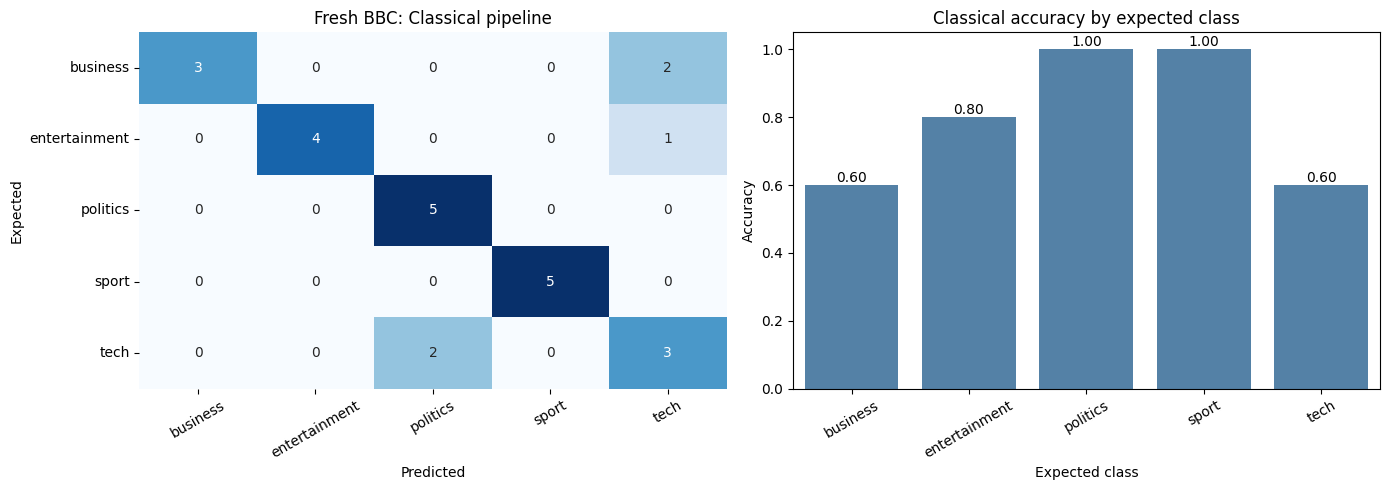

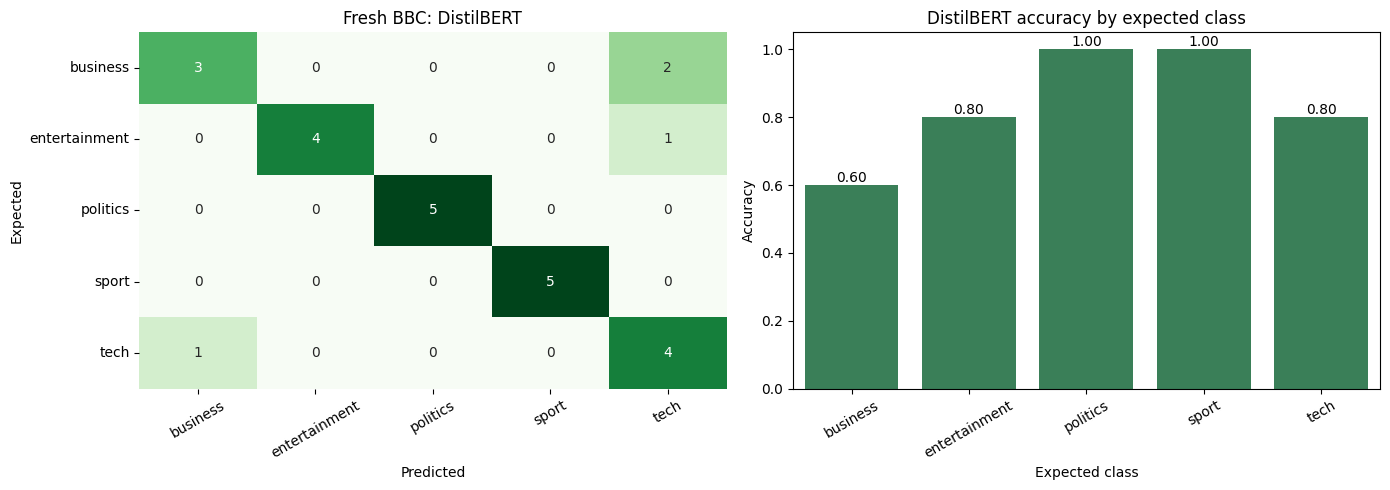

In [15]:
labels = ['business', 'entertainment', 'politics', 'sport', 'tech']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classical_cm = confusion_matrix(
    inference_df['expected_class'],
    inference_df['classical_label'],
    labels=labels,
)
sns.heatmap(
    classical_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0],
    cbar=False,
)
axes[0].set_title('Fresh BBC: Classical pipeline')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Expected')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

class_accuracy = (
    inference_df
    .groupby('expected_class')['classical_correct']
    .mean()
    .reindex(labels)
    .reset_index()
)
sns.barplot(
    data=class_accuracy,
    x='expected_class',
    y='classical_correct',
    ax=axes[1],
    color='steelblue',
)
axes[1].set_title('Classical accuracy by expected class')
axes[1].set_xlabel('Expected class')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=30)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

if 'distilbert_label' in inference_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    bert_cm = confusion_matrix(
        inference_df['expected_class'],
        inference_df['distilbert_label'],
        labels=labels,
    )
    sns.heatmap(
        bert_cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[0],
        cbar=False,
    )
    axes[0].set_title('Fresh BBC: DistilBERT')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Expected')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].tick_params(axis='y', rotation=0)

    bert_class_accuracy = (
        inference_df
        .groupby('expected_class')['distilbert_correct']
        .mean()
        .reindex(labels)
        .reset_index()
    )
    sns.barplot(
        data=bert_class_accuracy,
        x='expected_class',
        y='distilbert_correct',
        ax=axes[1],
        color='seagreen',
    )
    axes[1].set_title('DistilBERT accuracy by expected class')
    axes[1].set_xlabel('Expected class')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1.05)
    axes[1].tick_params(axis='x', rotation=30)

    for container in axes[1].containers:
        axes[1].bar_label(container, fmt='%.2f')

    plt.tight_layout()
    plt.show()

На финальной validation-части исходного BBC dataset классический пайплайн `TF-IDF + LogisticRegression` показал очень высокое качество. Это ожидаемо: рубрики BBC хорошо разделяются по лексике, а TF-IDF хорошо ловит характерные слова классов.

DistilBERT тоже решает задачу успешно и на свежих BBC-новостях показал немного более высокую точность. Улучшение есть, но оно небольшое, поэтому нельзя сказать, что DistilBERT радикально превосходит baseline на этой задаче. Его преимущество в том, что он использует контекстные представления текста и потенциально лучше переносится на новые формулировки и более сложные случаи. Цена этого преимущества - более долгое обучение, необходимость fine-tuning и заметно более тяжелый inference.

Ошибки на свежих новостях в основном связаны с пересечением рубрик. Например, business-статьи про технологические компании могут классифицироваться как `tech`, а tech-статьи про регулирование, запреты или государственные решения могут уходить в `politics`. Для классического TF-IDF это особенно естественно: модель ориентируется на лексику статьи, а не на редакционную логику BBC.

Если важны простота и скорость, классический `TF-IDF + LogisticRegression` является очень сильным baseline и практически достаточен для этой задачи. Если важнее качество на новых текстах и есть ресурсы на обучение, то DistilBERT можно считать лучшим решением, но его преимущество здесь незначительно.